In [ ]:
# Matthias Panny - 2026-09-08

import numpy as np
import matplotlib.pyplot as plt
from math import factorial, comb

### Signal

In [2]:
Ts = 1e-3

A = 1.5
f = 5

t = np.arange(0, 1, Ts)

y = A * np.sin(2 * np.pi * f * t) + 0.005 * np.random.randn(len(t))
y_d_exact = 2 * np.pi * f * A * np.cos(2 * np.pi * f * t)

### Kernel

In [3]:
# Parameters
T = 5e-2   # kernel window length
n = 4      # kernel order
r_max = 4  # max derivative order

# Base polynomial S(tau) for tau = t/T
max_order = 2*n + 1

Cn = factorial(max_order) / (factorial(n) ** 2)
S_p = np.zeros(max_order + 1)
for k in range(n + 1):
    idx = max_order - (n + k + 1)
    S_p[idx] = Cn * comb(n, k) * ((-1) ** k / (n + k + 1))

# Derivative polynomials phi(tau), scaled by 1/T^r for d/dt
# d^r/dt^r f(t/T) = (1/T^r) * d^r/dtau^r f(tau)
phi_polys = [None] * (r_max + 1)
phi_polys[0] = np.polyder(S_p)           # smoothing kernel

for r in range(0, r_max):
    phi_polys[r+1] = np.polyder(phi_polys[r]) / T

assert len(phi_polys) == r_max + 1, "phi_polys length mismatch"

### Only evaluate kernel over [0,T]

In [12]:
tau = t/T
idx_kernel = t <= T
tau_kernel = tau[idx_kernel]

### Normalization

In [13]:
phi_0th_deriv = np.polyval(phi_polys[0], tau_kernel)
norm_factor = np.sum(phi_0th_deriv)

### Derivative Kernels

In [17]:
deriv_order = 1  # 0 = smoothing, 1 = first derivative, ...
kernel = np.polyval(phi_polys[deriv_order], tau_kernel) / norm_factor

### Apply first derivative kernel

In [18]:
y_d = np.convolve(y, kernel, mode='same')
y_d_diff = np.diff(y) / Ts

### Plot

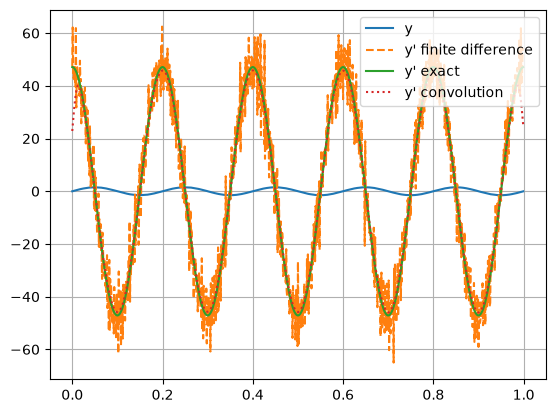

In [ ]:
plt.plot(t, y, alpha=0.5, label="y")
plt.plot(t[:-1], y_d_diff, "--", label="y' finite difference")
plt.plot(t, y_d_exact, label="y' exact")
plt.plot(t, y_d, ":", label="y' convolution")
plt.legend()
plt.grid(True)

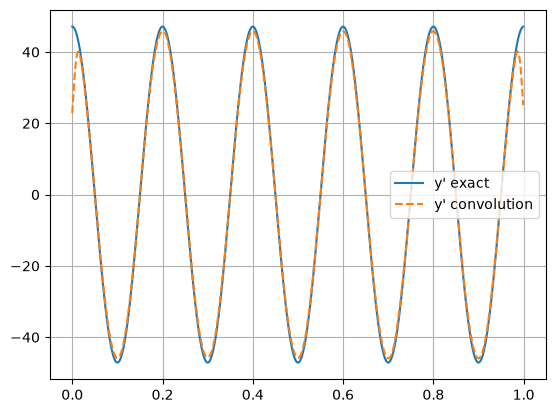

In [26]:
from smooth_deriv import SmoothDeriv

smoother = SmoothDeriv(Ts=Ts, T=5e-2)
y_d_conv_smoother = smoother(y, deriv_order=1)

plt.plot(t, y_d_exact, label="y' exact")
plt.plot(t, y_d_conv_smoother, "--", label="y' convolution")
plt.legend()
plt.grid(True)